In [1]:
# Importing Libraries
import ast # For string conversion into list object
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
plt.close('all')

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

# Highest Skills in Data Job Postings

In [2]:
# Filter df for jobs in United Kingdom
df_UK = df[(df["job_country"] == "United Kingdom")].copy()

# Explode job_skills list (unpivot this column)
df_skills = df_UK.explode("job_skills")

# Group by to see how many jobs per skill grouped by job title
df_skills_count = df_skills.groupby(["job_skills", "job_title_short"]).size()

# Convert this to a dataframe by resetting index and naminig the count column to skill_count
df_skills_count = df_skills_count.reset_index(name="skill_count")

# Sort df by skill count in ascending order. This is vital for correct data in plots
df_skills_count.sort_values(by="skill_count", ascending=False, inplace=True)

In [3]:
df_skills_count

,job_skills,job_title_short,skill_count
1163,sql,Data Engineer,7050
915,python,Data Engineer,6462
916,python,Data Scientist,6329
88,azure,Data Engineer,4865
1162,sql,Data Analyst,4467
...,...,...,...
1368,vue.js,Software Engineer,1
1367,vue.js,Senior Data Engineer,1
514,javascript,Machine Learning Engineer,1
551,julia,Software Engineer,1


## Change approach to this, and make target jobs into a list

In [4]:
# Retrieve top 3 job titles in a list
job_list = df_skills_count["job_title_short"].unique().tolist()
# Put list in alphabetical order
job_list = sorted(job_list[:3])
job_list

['Data Analyst', 'Data Engineer', 'Data Scientist']

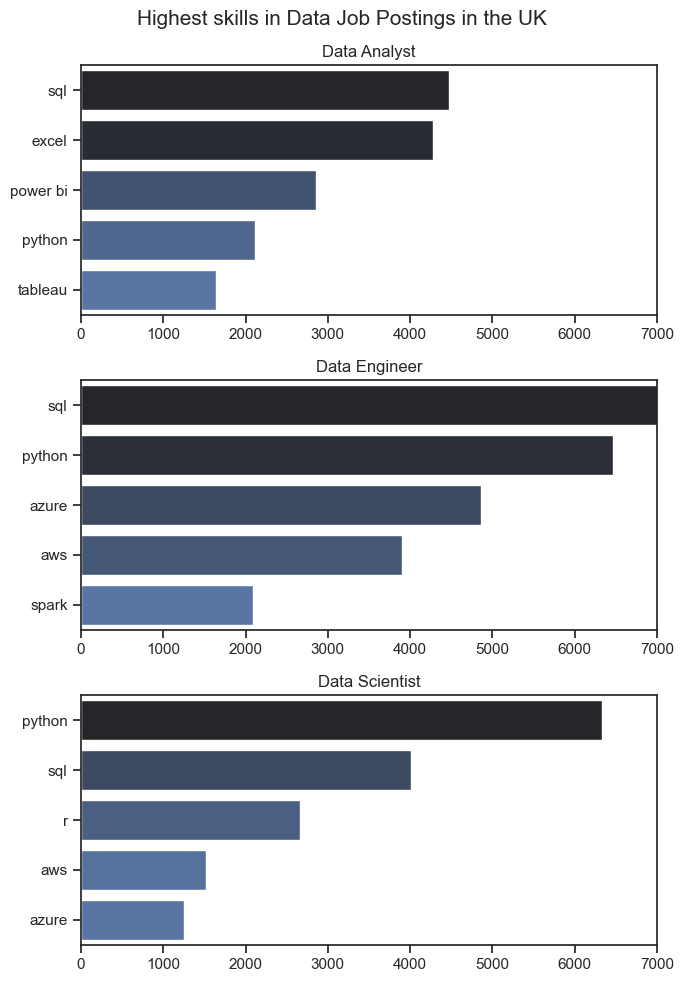

In [10]:
# Plot the top 3 job titles in subplots
fig, ax = plt.subplots(len(job_list), 1, figsize=(7, 10))
# Use for loop to interate over job_list and bring top 5 skills with highest counts 
for i, job_name in enumerate(job_list):
    df_plot = df_skills_count[df_skills_count["job_title_short"] == job_name].head(5)
    # Plot using Matplotlib
    # df_plot.sort_values(by="skill_count", ascending=True).plot(
    #     kind="barh",
    #     x="job_skills",
    #     y="skill_count",
    #     ax=ax[i], # Ensure subplots are plotted one after the other

    #     title=job_name,
    #     legend=False,
    # )
    # +_+_+_+_+_+_+_+_+_+_+_+_+_+_+_
    # Plot using Seaborn
    sns.barplot(
        data=df_plot,
        y="job_skills", # Swap x and y values to make it horizontal bar plot
        x="skill_count",
        ax=ax[i],
        legend=False,

        hue="skill_count",
        palette="dark:b_r"
    )
    ax[i].set_title(job_name)
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].set_xlim(0, 7000) # Ensure uniformity in x axis values

fig.suptitle("Highest skills in Data Job Postings in the UK", fontsize=15);
fig.tight_layout() # Prevent overlap between plots
plt.show();

# Likelihood of Skills in Data Job Postings

In [6]:
# Return total number of each job and make it into dataframe
df_job_counts = df_UK["job_title_short"].value_counts().reset_index(name="job_counts")

df_job_counts

,job_title_short,job_counts
0,Data Engineer,11807
1,Data Analyst,10482
2,Data Scientist,9148
3,Senior Data Engineer,3337
4,Senior Data Scientist,2367
5,Senior Data Analyst,1356
6,Business Analyst,827
7,Software Engineer,541
8,Machine Learning Engineer,317
9,Cloud Engineer,193


In [7]:
df_skills_percentage = pd.merge(df_skills_count, df_job_counts, how="left", on="job_title_short")

df_skills_percentage["Percentage"] = (df_skills_percentage["skill_count"] / df_skills_percentage["job_counts"]) * 100

In [8]:
df_skills_percentage

,job_skills,job_title_short,skill_count,job_counts,Percentage
0,sql,Data Engineer,7050,11807,59.710341
1,python,Data Engineer,6462,11807,54.730245
2,python,Data Scientist,6329,9148,69.184521
3,azure,Data Engineer,4865,11807,41.204370
4,sql,Data Analyst,4467,10482,42.615913
...,...,...,...,...,...
1414,vue.js,Software Engineer,1,541,0.184843
1415,vue.js,Senior Data Engineer,1,3337,0.029967
1416,javascript,Machine Learning Engineer,1,317,0.315457
1417,julia,Software Engineer,1,541,0.184843


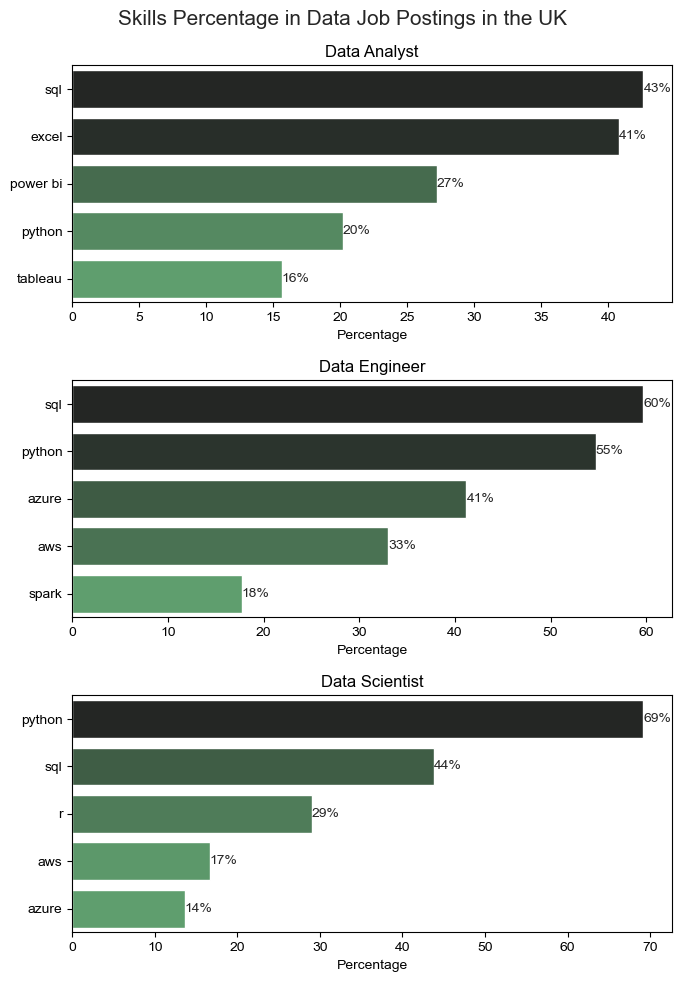

In [9]:
# Plot the top 3 job titles in subplots as percentages
fig, ax = plt.subplots(len(job_list), 1, figsize=(7, 10))
sns.set_theme(style="ticks")

# Use for loop to interate over job_list and bring top 5 skills with highest counts 
for i, job_name in enumerate(job_list):
    df_plot = df_skills_percentage[df_skills_percentage["job_title_short"] == job_name].head(5)
    # Plot using Matplotlib
    # df_plot.sort_values(by="skill_count", ascending=True).plot(
    #     kind="barh",
    #     x="job_skills",
    #     y="Percentage", # Change this to Percentage column
    #     ax=ax[i], # Ensure subplots are plotted one after the other

    #     title=job_name,
    #     legend=False,
    # )
    # +_+_+_+_+_+_+_+_+_+_+_+_+_+_+_
    # Plot using Seaborn
    sns.barplot(
        data=df_plot,
        y="job_skills", # Swap x and y values to make it horizontal bar plot
        x="Percentage",
        ax=ax[i],
        legend=False,

        hue="Percentage",
        palette="dark:g_r"
    )
    ax[i].set_title(job_name)
    ax[i].set_ylabel("")

    # Add the percentage datalabels for each bar
    # NOTE: container is the group of bars inside a plot, so we access the data value in each container
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt="%.0f%%", fontsize=10)
    

fig.suptitle("Skills Percentage in Data Job Postings in the UK", fontsize=15)
fig.tight_layout(); # Prevent overlap between plots

plt.show()
